# <span style="color:black; font-weight:bold;">Cross-modal alignment and diagonal integration liver cancer Tutorial</span>
+ <span style="color:black; font-weight:bold;">Creator</span>: Bingjie Dai (17516970902@163.com)
+ <span style="color:black; font-weight:bold;">Date of Creation</span>: 6.23.2026
+ <span style="color:black; font-weight:bold;">Date of Last Modification</span>: 6.23.2026
+ <span style="color:black; font-weight:bold;">Download</span>: Cross-modal liver cancer data used in the tutorial are available at [L28meta.h5ad](https://drive.google.com/file/d/1yd0l1KrdIV0vxYH-Exlo3pDbU46_1N-7/view?usp=sharing) and [L_28.h5ad](https://drive.google.com/file/d/19i8paWKObFjRRpmsP1C-hSSrxbjaiwbS/view?usp=sharing). The raw data is from [PNAS](https://doi.org/10.1073/pnas.2505789122).
In this tutorial we apply MAPS to align and integrate MALDI-MSI and 10xVisium dataset

<span style="color:black; font-weight:bold;">The dataset have:</span>   
+ <span style="color:black; font-weight:bold;">MALDI-MSI(SM)</span>: 48,839 spots and 1155 mz   
+ <span style="color:black; font-weight:bold;">10xVisium(ST)</span>: 3766 spots and 18,085 genes

In [1]:
from MAPS.align import Rigid_alignment
from MAPS.utils import set_seed,rotate_and_translate_spatial,prepare_paired_inputs,create_new_color_dict
from MAPS.modal_integration import COI
import scanpy as sc
import pandas as pd
import torch
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
set_seed(2026)

## <span style="color:black; font-weight:bold;">Loading Cross-modal liver cancer data (MALDI-MSI-metabolism and 10xVisium-RNA)</span>
#### To ensure the accuracy of the scaling factor, we recommend using the slice with a larger initial coordinate range as the target_adata for learning the scaling factor.

In [4]:
source_adata=sc.read_h5ad('/home/dbj/LPcross/Data/meta-RNA/L28meta.h5ad')
source_adata.obs['batch']='MALDI-MSI(SM)'
sc.pp.normalize_total(source_adata,inplace=True)
sc.pp.log1p(source_adata)

target_adata=sc.read_h5ad('/home/dbj/LPcross/Data/meta-RNA/RNA_liver0508/L_28.h5ad')
target_adata.obs['batch']='10xVisium(ST)'
sc.pp.highly_variable_genes(target_adata, n_top_genes=2000, flavor='seurat_v3',subset=True)
sc.pp.normalize_total(target_adata,inplace=True)
sc.pp.log1p(target_adata)

target_adata.var_names_make_unique()
source_adata.var_names_make_unique()

### Rotate and translate the MERFISH data

In [5]:
rotate_and_translate_spatial(source_adata,angle_deg=45,dx=500,dy=400)

## <span style="color:black; font-weight:bold;">Spatial mapping of the liver cancer before alignment</span>

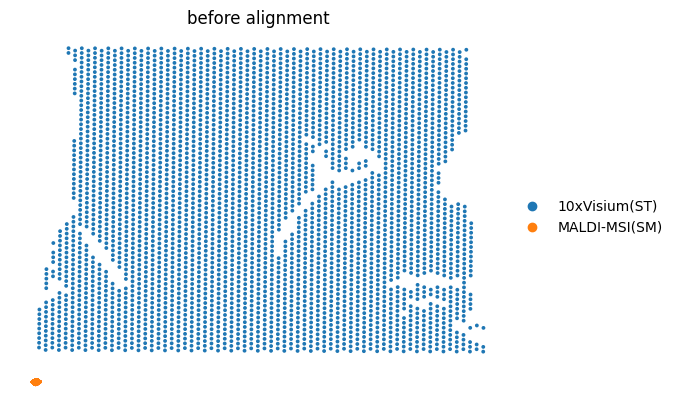

In [6]:
adata=sc.concat([source_adata,target_adata],join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color='batch',title='before alignment',size=30,frameon=False)

## <span style="color:black; font-weight:bold;">Align the slices using MAPS</span> 
### <span style="color:black; font-weight:bold;">Training parameters</span> 
epochs: Training ephchs  
device: Training device  
sample_size: The number of samples used for alignment  
enable_scale: Whether to learn the scaling factor?  

### <span style="color:black; font-weight:bold;">Output</span>   
aligned_spatial: The coordinates of the source slices after alignment  
theta_deg: Angle of rotation  
translation: Translation matrix  
scale: Scaling factor

In [7]:
%%time
source = source_adata.obsm['spatial'].astype(np.float32) 
target = target_adata.obsm['spatial'].astype(np.float32)  

aligned_spatial, theta_deg, translation,scale= Rigid_alignment(source, target, epochs=2000, sample_size=20000,enable_scale=True,device=device)
source_adata.obsm['spatial'] = aligned_spatial

Scanning angles to find best starting angle...


Global Align: 100%|█████████████████████████████| 2000/2000 [00:08<00:00, 238.88it/s, Loss=138.75, Scale=93.891, Rot=46.60°, Trans=(10725.1, 14038.1)]


Peak GPU memory usage: 0.932 GB
Scale factor: 93.889, Rotation angle: 46.10°, Translation (x, y): (10725.23, 14038.27)
CPU times: user 8.64 s, sys: 1.13 s, total: 9.77 s
Wall time: 10.1 s


## <span style="color:black; font-weight:bold;">Spatial mapping of the liver cancer after alignment</span>

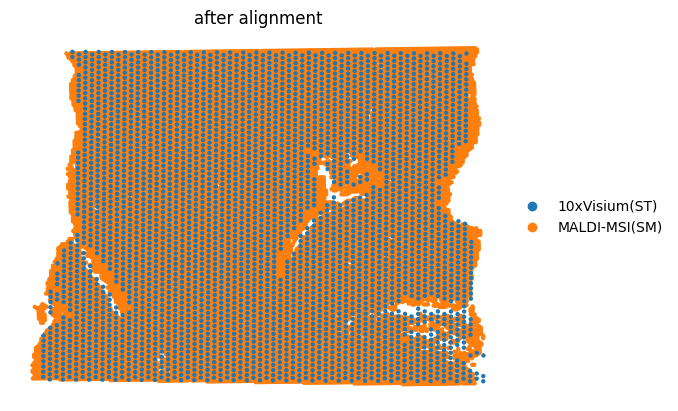

In [8]:
adata=sc.concat([source_adata,target_adata],join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color=['batch'],title='after alignment',size=40,frameon=False)

## <span style="color:black; font-weight:bold;">Compute the cross-slice connection index matrix</span> 
### <span style="color:black; font-weight:bold;">Parameters</span> 
k_intra: K nearest neighbors within slice   
k_inter: K nearest neighbors between slices

In [9]:
source_adata.obsm['feat']=source_adata.X
target_adata.obsm['feat']=target_adata.X
graph1, graph2, idx_1_to_2 = prepare_paired_inputs(source_adata=source_adata, target_adata=target_adata, k_intra=6, k_inter=6, device=device)

## <span style="color:black; font-weight:bold;">Initialize the diagonal integration model</span> 

In [10]:
model = COI(in_channels1=graph1.features.shape[1],in_channels2=graph2.features.shape[1], out_channels=32)

## <span style="color:black; font-weight:bold;">Train diagonal integration model</span> 
### <span style="color:black; font-weight:bold;">Parameters</span> 
epochs: Training ephchs  
device: Training device  
seed: Random seed

In [11]:
model.Train(graph1,graph2,idx_1_to_2,epochs=2000,lr=1e-3,device=device,seed=7)

Cross-modal integration: 100%|████████| 2000/2000 [00:54<00:00, 36.63it/s, Epoch=1999, Loss=0.445, Loss1=0.056, Loss2=0.284, Loss3=0.081, Loss4=0.005]


## <span style="color:black; font-weight:bold;">Output the reconstructed expression matrix and embedding</span> 

In [12]:
embedding1, embedding2,reconstructed1,reconstructed2 = model.get_embedding(graph1,graph2,idx_1_to_2)

In [13]:
source_adata.obsm['MAPS']=embedding1
target_adata.obsm['MAPS']=embedding2
source_adata.layers['rec']=reconstructed1
target_adata.layers['rec']=reconstructed2

## <span style="color:black; font-weight:bold;">Downstream analysis (kmeans and UMAP)</span> 

In [14]:
from sklearn.cluster import KMeans
adata=sc.concat([source_adata,target_adata],join='inner')

#leiden umap
sc.pp.neighbors(adata,use_rep='MAPS',n_neighbors=30)
sc.tl.umap(adata)
# KMeans 
kmeans = KMeans(n_clusters=8, random_state=2026) 
labels = kmeans.fit_predict(adata.obsm['MAPS'])
adata.obs['MAPS_kmeans']=labels.astype(str)

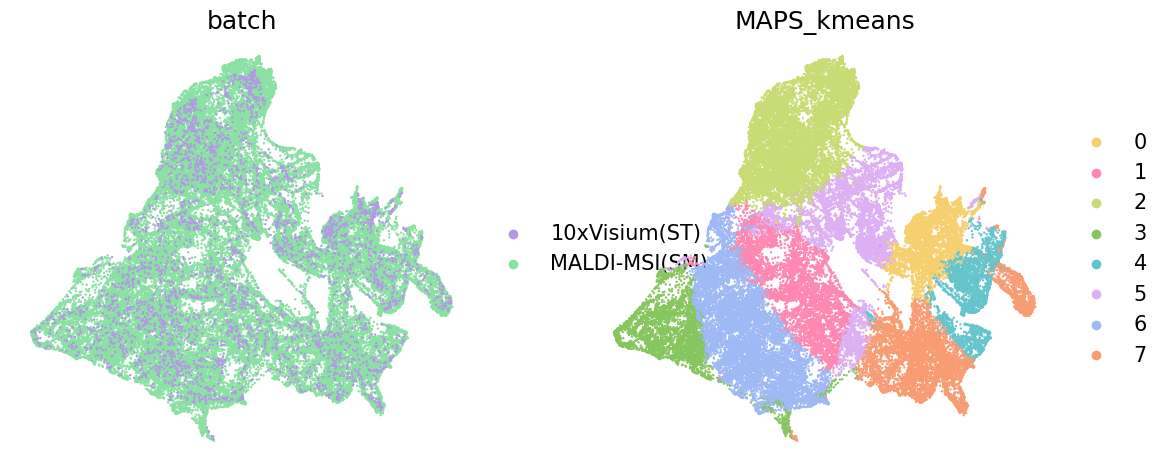

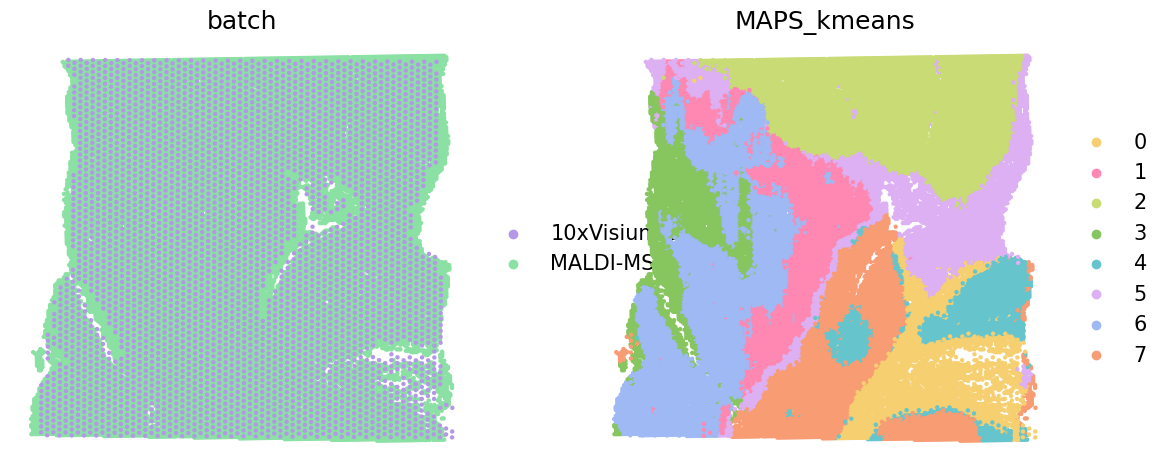

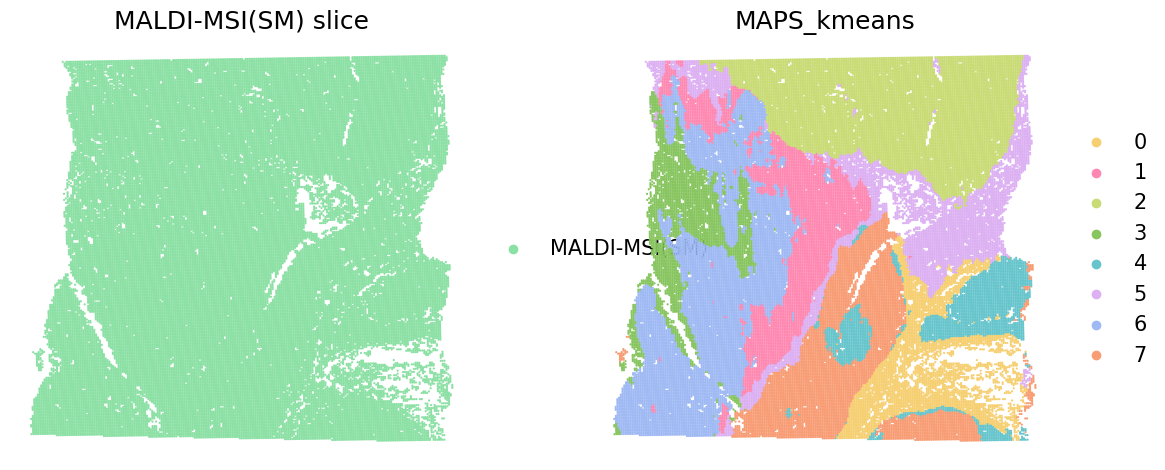

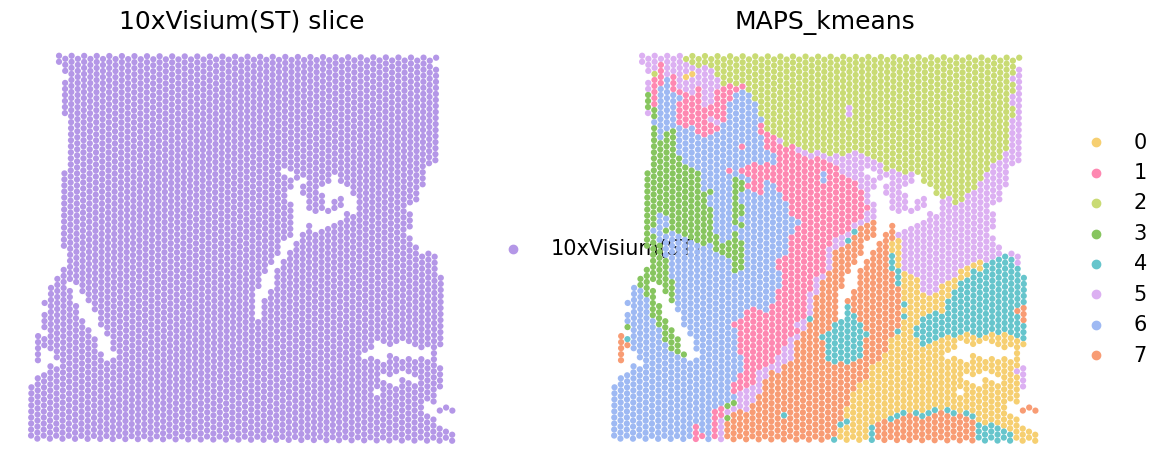

In [15]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (6,5.5)
plt.rcParams['font.size'] = 15
color_dict1=create_new_color_dict(adata,cat_key='batch',skip_default_colors=8)
color_dict2=create_new_color_dict(adata,cat_key='MAPS_kmeans')
color_dict = color_dict1 | color_dict2

source_adata.obs['MAPS_kmeans']=adata.obs['MAPS_kmeans']
target_adata.obs['MAPS_kmeans']=adata.obs['MAPS_kmeans']

sc.pl.umap(adata=adata,color=['batch','MAPS_kmeans'],size=12,frameon=False,palette=color_dict)
sc.pl.embedding(adata=adata,color=['batch','MAPS_kmeans'],basis='spatial',size=40,frameon=False,palette=color_dict)
sc.pl.embedding(adata=source_adata,color=['batch','MAPS_kmeans'],basis='spatial',title='MALDI-MSI(SM) slice',size=10,frameon=False,palette=color_dict)
sc.pl.embedding(adata=target_adata,color=['batch','MAPS_kmeans'],basis='spatial',title='10xVisium(ST) slice',size=80,frameon=False,palette=color_dict)